# Topic 2 : Deep Learning  
## SVHN Image Classification using Convolutional Neural Networks (CNN)

**Dataset:** SVHN Dataset  
**Main Algorithm:** Convolutional Neural Network (CNN)  

<div style="text-align: center;">
    <img src="../img/svhn_dataset.png" style="width:650px; height:500px;"><br>
</div>

---

# 1. Introduction  

## 1.1 Overview  
This project builds an image classification model that can recognize handwritten digits from street view house number images using a Convolutional Neural Network (CNN). This is a supervised deep learning problem, where the model is trained using labeled image data and learns visual patterns to classify new unseen images correctly.  

The objective of this project is to classify digit images into one of the ten numerical classes (0–9) using deep learning techniques.  


## 1.2 Dataset Description  
The SVHN (Street View House Numbers) dataset is a real-world image dataset widely used for developing machine learning and deep learning algorithms for image recognition and classification tasks.  

The dataset contains colored images of digits collected from house numbers in Google Street View images. Each image has a resolution of **32 × 32 pixels** with three RGB color channels.  

The dataset contains:  

- **73,257 training images**  
- **26,032 testing images**  
- **531,131 additional training images**  

Each image belongs to one of **10 digit classes**:  

- **0**
- **1**
- **2**
- **3**
- **4**
- **5**
- **6**
- **7**
- **8**
- **9**

The input variable (**X**) represents the image pixel values, while the target variable (**y**) represents the corresponding digit label.  

Because the dataset contains multiple digit categories, this task is considered a multiclass image classification problem.  


## 1.3 Algorithm: Convolutional Neural Network (CNN)  

In this project, we use a **Convolutional Neural Network (CNN)** for image classification.  

CNN is one of the most powerful deep learning algorithms for computer vision tasks. It automatically learns important visual features such as edges, shapes, textures, and patterns directly from image data.  

The CNN model used in this project consists of several layers, including:  

- Convolutional layers  
- Activation layers (ReLU)  
- Pooling layers  
- Fully connected layers  
- Output layer with Softmax activation  

Key characteristics of CNN:  

- Automatically extracts image features  
- Performs well on image classification tasks  
- Reduces manual feature engineering  
- Learns complex visual patterns effectively  
- Achieves high accuracy for computer vision problems  

Because of these advantages, CNN is highly suitable for classifying SVHN digit images.

---



## 2. Step 1: Installing Deep Learning Frameworks

In this project, the TensorFlow deep learning framework was used to build and train the Convolutional Neural Network (CNN) model.

The required libraries were installed using pip:

```python
pip install tensorflow
pip install numpy
pip install matplotlib
pip install seaborn
pip install scipy
pip install scikit-learn
```

After installation, the libraries were imported into the Python environment and used for data preprocessing, model construction, training, evaluation, and visualization.

In [116]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import loadmat
import tensorflow as tf
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
import h5py

%matplotlib inline
plt.rcParams['figure.figsize'] = (16.0, 4.0)

## 2. Step 2: Loading the Dataset

The SVHN dataset was loaded using the `.mat` files provided by the official dataset source.  

The training and testing datasets were loaded separately using `loadmat()` from SciPy.  

The image data was then preprocessed by:
- Transposing the image dimensions
- Converting label `10` to digit `0`
- Normalizing pixel values to improve CNN training performance

In [117]:
def load_data(path):
    data = loadmat(path)
    return data['X'], data['y']

X_train, y_train = load_data('../data/train_32x32.mat')
X_test, y_test = load_data('../data/test_32x32.mat')

print("Training Set", X_train.shape, y_train.shape)
print("Test Set", X_test.shape, y_test.shape)

Training Set (32, 32, 3, 73257) (73257, 1)
Test Set (32, 32, 3, 26032) (26032, 1)


Transposing the the train and test data by converting it from  
(width, height, channels, size) -> (size, width, height, channels)

In [118]:
X_train, y_train = X_train.transpose((3,0,1,2)), y_train[:,0]
X_test, y_test = X_test.transpose((3,0,1,2)), y_test[:,0]

num_images = X_train.shape[0] + X_test.shape[0]

print("Total Number of Images", num_images)

Total Number of Images 99289


Plotting Function for fig in n rows X m columns

In [119]:
def plot_images_train(img, labels, nrows, ncols):
    fig, axes = plt.subplots(nrows, ncols, figsize=(12,6))
    axes = np.array(axes).reshape(-1)

    for i, ax in enumerate(axes):

        if img[i].shape == (32, 32, 3):
            ax.imshow(img[i])
        else:
            ax.imshow(img[i,:,:,0], cmap='gray')

        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f"{labels[i]}")

    plt.tight_layout()
    plt.show()
    

def plot_images(images, nrows, ncols, cls_true, cls_pred=None):
    fig, axes = plt.subplots(nrows, ncols)
    fig.tight_layout()

    rs = np.random.choice(images.shape[0], nrows * ncols)

    for ax, i in zip(axes.flat, rs):

        if cls_pred is None:
            title = f"T: {cls_true[i]}"
        else:
            title = f"T: {cls_true[i]}, P: {cls_pred[i]}"

        ax.imshow(images[i, :, :, 0], cmap='binary')
        ax.set_title(title)
        ax.set_xticks([])
        ax.set_yticks([])

    plt.show()

Plot some training set images

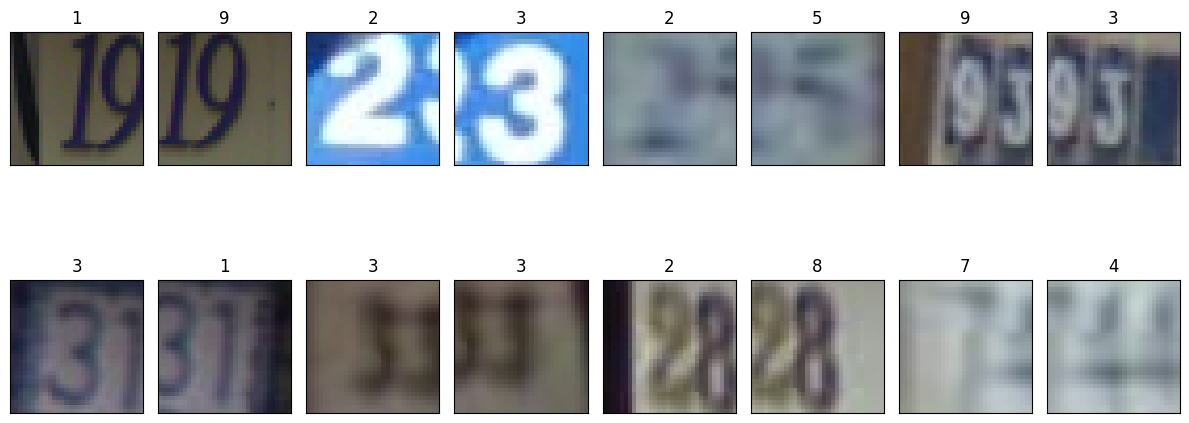

<Figure size 1600x400 with 0 Axes>

In [120]:
plot_images_train(X_train, y_train, 2, 8)
plt.savefig('../img/training_samples.png', dpi=150, bbox_inches='tight')
plt.show() 

Plot some testing set images

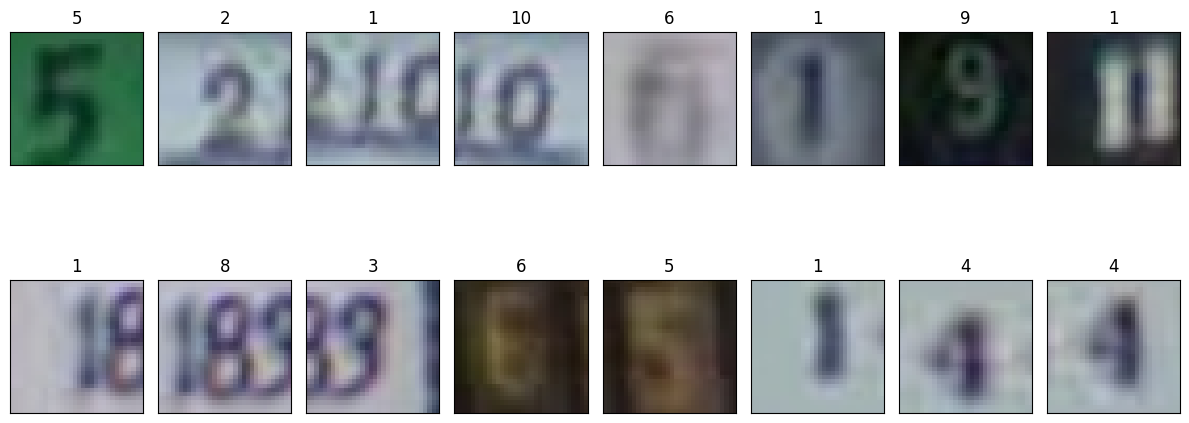

<Figure size 1600x400 with 0 Axes>

In [121]:
plot_images_train(X_test, y_test, 2, 8)
plt.savefig('../img/test_samples.png', dpi=150, bbox_inches='tight')
plt.show()

Class Distribution

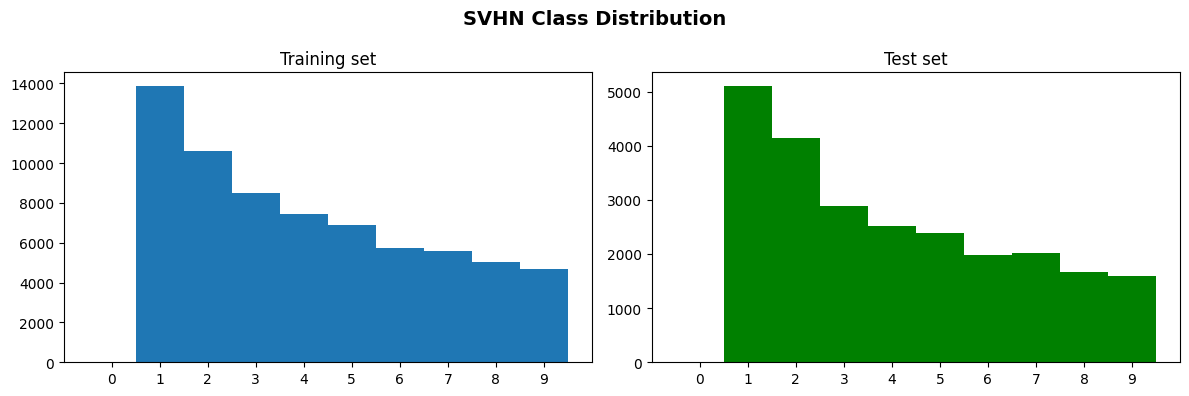

In [122]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4), sharex=True)

fig.suptitle('SVHN Class Distribution', fontsize=14, fontweight='bold')

bins = np.arange(-0.5, 10.5, 1)

ax1.hist(y_train, bins=bins)
ax1.set_title("Training set")
ax1.set_xticks(range(10))

ax2.hist(y_test, bins=bins, color='g')
ax2.set_title("Test set")
ax2.set_xticks(range(10))

plt.tight_layout()
plt.savefig('../img/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Data Preprocessing

In this step, the dataset is prepared for training by correcting label values and normalizing image data.

1. Label Correction
In the dataset, the digit **0 is originally labeled as 10**. To ensure consistency in classification (0–9), all occurrences of label `10` are replaced with `0`.

2. Data Normalization
To improve training performance and stability, the pixel values of the images are normalized from the range `[0, 255]` to `[0, 1]`.


In [123]:
y_train[y_train == 10] = 0
y_test[y_test == 10] = 0

print(np.unique(y_train))

# Normalization
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

[0 1 2 3 4 5 6 7 8 9]


### Train-Validation Split

The training data is split into training and validation sets using a 70/30 ratio. This helps evaluate model performance during training and reduces overfitting. A fixed random state is used to ensure reproducibility.

In [124]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.3, random_state=42)

### One-Hot Encoding of Labels

The class labels are converted into one-hot encoded vectors to make them suitable for multi-class classification using a neural network. This transforms each label into a binary vector of length 10, where only the correct class index is set to 1.

After encoding, the shapes of the training, validation, and test sets are checked to confirm the transformation.

In [125]:
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_val = tf.keras.utils.to_categorical(y_val, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

print("Training set", y_train.shape)
print("Validation set", y_val.shape)
print("Test set", y_test.shape)

Training set (51279, 10)
Validation set (21978, 10)
Test set (26032, 10)


Storing Data to Disk

In [126]:
try:
    h5f.close()
except:
    pass

h5f = h5py.File('../data/SVHN_RGB.h5', 'w')

h5f.create_dataset('X_train', data=X_train)
h5f.create_dataset('y_train', data=y_train)

h5f.create_dataset('X_test', data=X_test)
h5f.create_dataset('y_test', data=y_test)

h5f.create_dataset('X_val', data=X_val)
h5f.create_dataset('y_val', data=y_val)

h5f.close()

## 3. Step 3: Constructing a Convolutional Neural Network

In this step, a Convolutional Neural Network (CNN) is built to perform image classification. The architecture and implementation depend on the chosen deep learning framework, and standard CNN design practices are followed based on available tutorials and best practices. The model typically consists of convolutional layers for feature extraction, pooling layers for dimensionality reduction, and fully connected layers for final classification.

Loading Data

In [127]:
h5f = h5py.File('../data/SVHN_RGB.h5', 'r')

X_train = h5f['X_train'][:]
y_train = h5f['y_train'][:]
X_test = h5f['X_test'][:]
y_test = h5f['y_test'][:]
X_val = h5f['X_val'][:]
y_val = h5f['y_val'][:]

h5f.close()

print('Training set', X_train.shape, y_train.shape)
print('Validation set', X_val.shape, y_val.shape)
print('Test set', X_test.shape, y_test.shape)

Training set (51279, 32, 32, 3) (51279, 10)
Validation set (21978, 32, 32, 3) (21978, 10)
Test set (26032, 32, 32, 3) (26032, 10)


Get Batch Dynamically

In [128]:
def get_batch(X, y, batch_size=512):
    for i in np.arange(0, y.shape[0], batch_size):
        end = min(X.shape[0], i + batch_size)
        yield(X[i:end],y[i:end])

### CNN Model Construction and Compilation

A Convolutional Neural Network (CNN) is built for a 10-class image classification task using TensorFlow/Keras. The model follows a standard deep learning architecture designed to extract hierarchical features from images.

#### Architecture Overview

The network starts with an input layer that accepts 32×32 RGB images. It then passes through three convolutional blocks, each consisting of a Conv2D layer followed by max pooling. These layers progressively extract more complex visual features while reducing spatial dimensions.

After feature extraction, the output is flattened into a 1D vector and passed through a fully connected (Dense) layer with dropout regularization to reduce overfitting. Finally, the output layer uses softmax activation to produce probability distributions across 10 classes.

#### Compilation

The model is compiled using the Adam optimizer, categorical crossentropy loss function (suitable for multi-class classification), and accuracy as the evaluation metric.

#### Optimization (Adam)

The Adam optimizer was used for training. It is an adaptive learning rate optimization algorithm that combines the benefits of Momentum and RMSprop.

Adam automatically adjusts the learning rate during training, which helps achieve faster convergence and stable performance without manual tuning.

In [129]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3), name='Input_Data'),

    # First convolution block
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2,2)),

    # Second convolution block
    tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2,2)),

    # Third convolution block
    tf.keras.layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2,2)),

    # Flatten for dense layers
    tf.keras.layers.Flatten(),

    # Fully connected layer
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    # Output layer
    tf.keras.layers.Dense(10, activation='softmax', name='Output_Layer')
])

model.summary()

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 620,362 (2.37 MB)

 Trainable params: 620,362 (2.37 MB)

 Non-trainable params: 0 (0.00 B)

CNN Network Structure Diagram


<div style="text-align: center;">
    <p>CNN Network Structure Diagram</p>
    <img src="../img/cnn_diagram.png" style="width:650px; height:500px; pos"><br>
</div>

## Model Training

The model is trained on the training set and evaluated on the validation set over 10 epochs. A batch size of 64 is used, and the training history is saved for later analysis.

In [130]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

datagen.fit(X_train)

In [131]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    validation_data=(X_val, y_val),
    epochs=10
)

Epoch 1/10
802/802 ━━━━━━━━━━━━━━━━━━━━ 35s 42ms/step - accuracy: 0.5264 - loss: 1.3994 - val_accuracy: 0.8500 - val_loss: 0.5256
Epoch 2/10
802/802 ━━━━━━━━━━━━━━━━━━━━ 36s 45ms/step - accuracy: 0.7779 - loss: 0.7189 - val_accuracy: 0.8844 - val_loss: 0.3822
Epoch 3/10
802/802 ━━━━━━━━━━━━━━━━━━━━ 38s 47ms/step - accuracy: 0.8183 - loss: 0.5888 - val_accuracy: 0.8987 - val_loss: 0.3393
Epoch 4/10
802/802 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step - accuracy: 0.8408 - loss: 0.5155 - val_accuracy: 0.9030 - val_loss: 0.3255
Epoch 5/10
802/802 ━━━━━━━━━━━━━━━━━━━━ 37s 46ms/step - accuracy: 0.8528 - loss: 0.4826 - val_accuracy: 0.9085 - val_loss: 0.3083
Epoch 6/10
802/802 ━━━━━━━━━━━━━━━━━━━━ 37s 46ms/step - accuracy: 0.8610 - loss: 0.4589 - val_accuracy: 0.9130 - val_loss: 0.2970
Epoch 7/10
802/802 ━━━━━━━━━━━━━━━━━━━━ 36s 45ms/step - accuracy: 0.8698 - loss: 0.4312 - val_accuracy: 0.9163 - val_loss: 0.2833
Epoch 8/10
802/802 ━━━━━━━━━━━━━━━━━━━━ 36s 45ms/step - accuracy: 0.8755 - loss: 0.4118 - 

### Model Evaluation

The model is evaluated on the test set using accuracy, precision, recall, and F1-score. Predictions are compared with true labels to measure overall classification performance.

In [132]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Calculate metrics
loss, accuracy = model.evaluate(X_test, y_test)
precision = precision_score(y_true_classes, y_pred_classes, average='weighted')
recall = recall_score(y_true_classes, y_pred_classes, average='weighted')
f1 = f1_score(y_true_classes, y_pred_classes, average='weighted')

print(' ')
print(f'Test Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision* 100:.2f}%')
print(f'Recall: {recall* 100:.2f}%')
print(f'F1-Score: {f1* 100:.2f}%')

814/814 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step
814/814 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9266 - loss: 0.2611
 
Test Accuracy: 92.66%
Precision: 92.72%
Recall: 92.66%
F1-Score: 92.66%


In [141]:
# Class classification report
from sklearn.metrics import classification_report
print(classification_report(y_true_classes, y_pred_classes, target_names=[str(i) for i in range(10)]))

              precision    recall  f1-score   support

           0       0.96      0.89      0.92      1744
           1       0.95      0.96      0.95      5099
           2       0.96      0.95      0.95      4149
           3       0.91      0.90      0.90      2882
           4       0.94      0.95      0.94      2523
           5       0.90      0.94      0.92      2384
           6       0.87      0.92      0.89      1977
           7       0.96      0.91      0.94      2019
           8       0.87      0.86      0.87      1660
           9       0.90      0.91      0.90      1595

    accuracy                           0.93     26032
   macro avg       0.92      0.92      0.92     26032
weighted avg       0.93      0.93      0.93     26032



## 4. Step 4: Result Visualization

The model’s performance is visualized using training and validation accuracy and loss curves. These plots provide an intuitive understanding of the learning process and show how the model improves over training epochs.

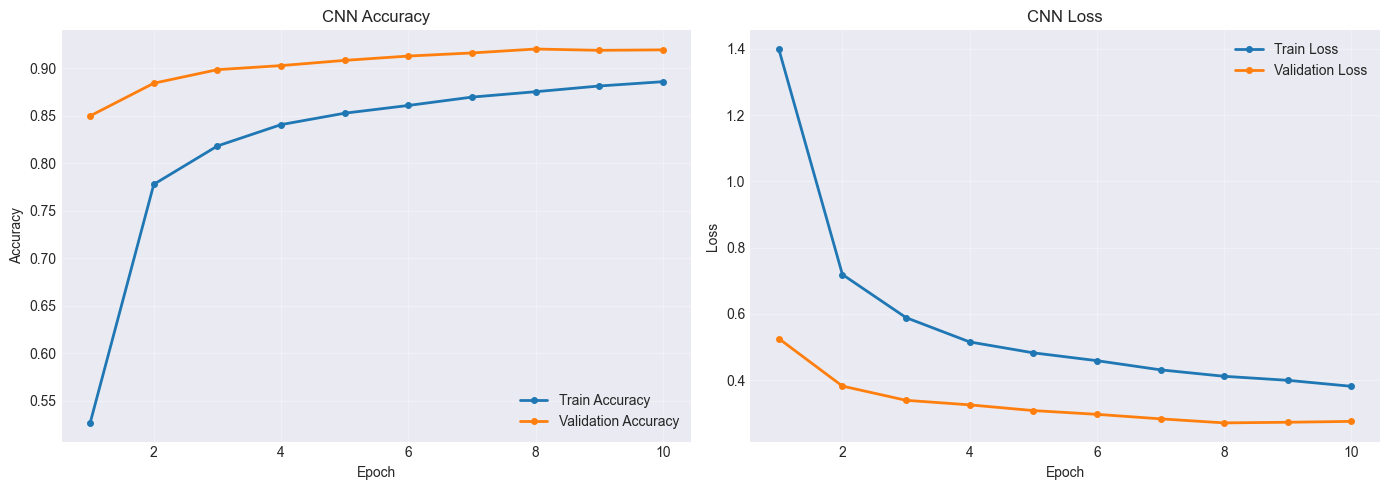

In [140]:
# Optional: nicer style
plt.style.use('seaborn-v0_8-darkgrid')

epochs = range(1, len(history.history['accuracy']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ===== Accuracy =====
ax1.plot(epochs, history.history['accuracy'], 'o-', label='Train Accuracy', linewidth=2, markersize=4)
ax1.plot(epochs, history.history['val_accuracy'], 'o-', label='Validation Accuracy', linewidth=2, markersize=4)

ax1.set_title('CNN Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# ===== Loss =====
ax2.plot(epochs, history.history['loss'], 'o-', label='Train Loss', linewidth=2, markersize=4)
ax2.plot(epochs, history.history['val_loss'], 'o-', label='Validation Loss', linewidth=2, markersize=4)

ax2.set_title('CNN Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig('../img/training_history.png', dpi=200, bbox_inches='tight')
plt.show()

### Confusion Matrix

A normalized confusion matrix is used to evaluate how well the model predicts each class. It is visualized as a heatmap for easier interpretation.

814/814 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step


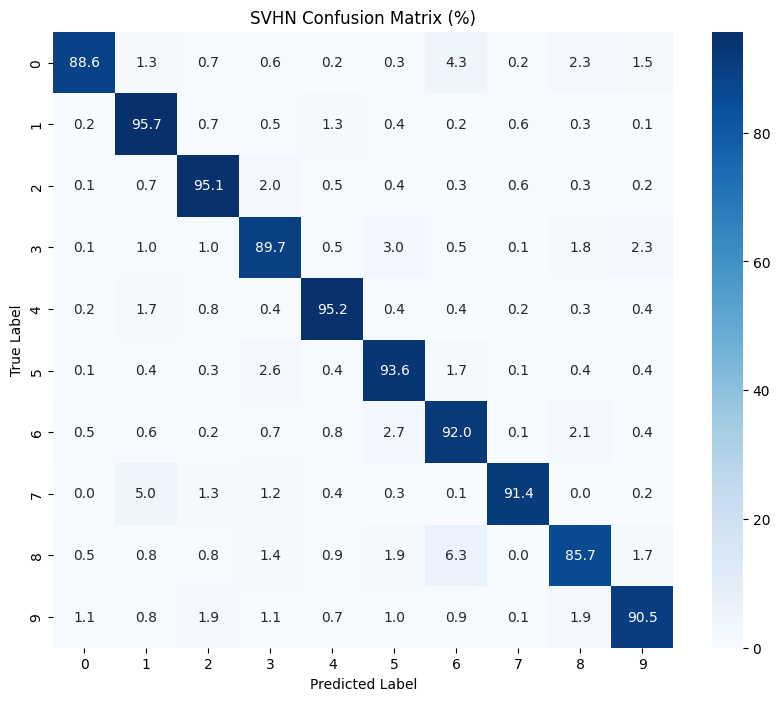

In [134]:
from sklearn.metrics import confusion_matrix

# Get predictions (if not already computed)
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Safe normalization (avoid division by zero)
cm = cm / (cm.sum(axis=1, keepdims=True) + 1e-8) * 100

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt=".1f", cmap='Blues')

plt.title('SVHN Confusion Matrix (%)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig('../img/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### Misclassified Samples

Incorrect predictions are extracted from the test set and visualized to analyze the model’s errors. This helps identify patterns in misclassification and understand where the model struggles.

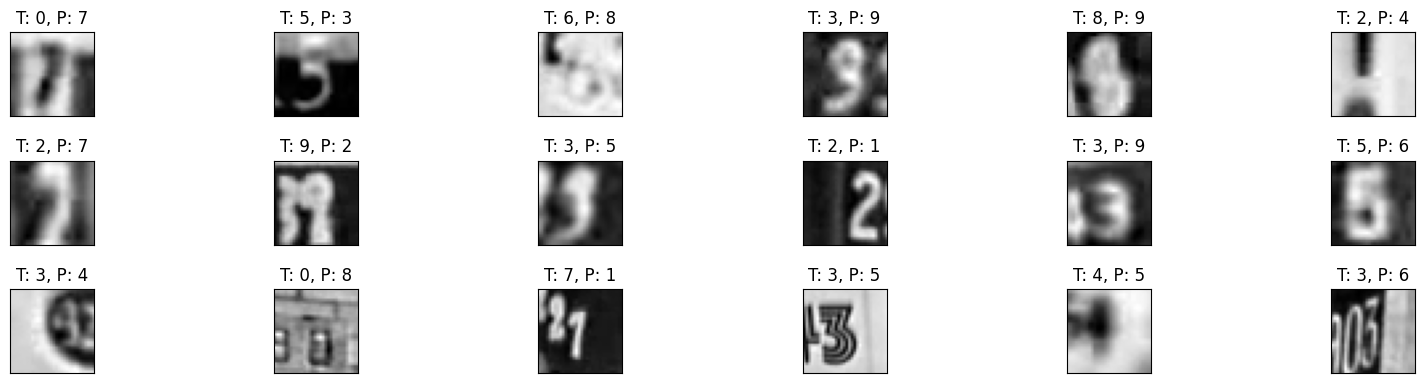

<Figure size 1600x400 with 0 Axes>

In [135]:
incorrect = y_pred != y_true

images = X_test[incorrect]
cls_true = y_true[incorrect]
cls_pred = y_pred[incorrect]

plot_images(images, 3, 6, cls_true, cls_pred)
plt.savefig('../img/misclassified_samples.png', dpi=150, bbox_inches='tight')
plt.show()

### Correctly Classified Samples

Correct predictions from the test set are visualized to show examples where the model performs well. This helps illustrate the model’s strengths in recognizing different classes.

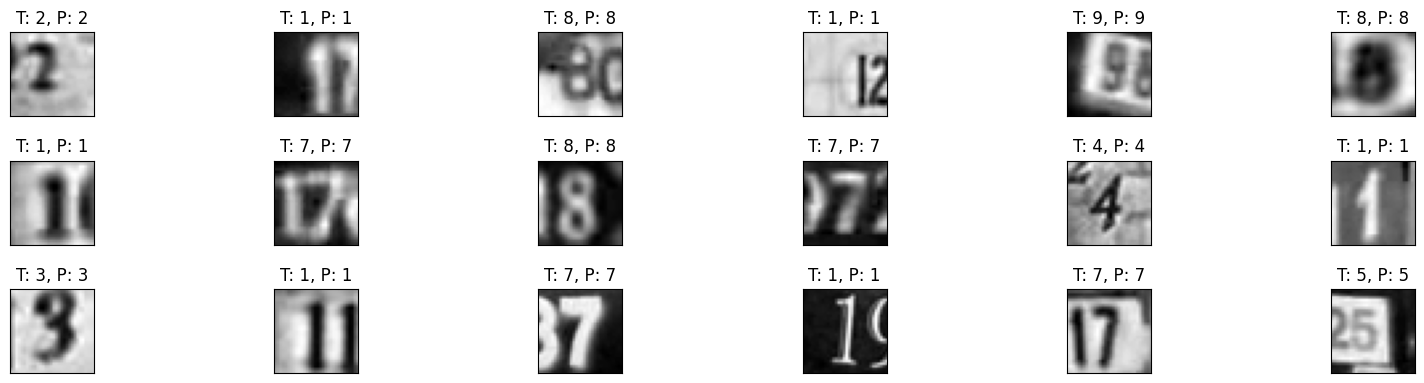

<Figure size 1600x400 with 0 Axes>

In [136]:
correct = y_pred == y_true

images = X_test[correct]
cls_true = y_true[correct]
cls_pred = y_pred[correct]

plot_images(images, 3, 6, cls_true, cls_pred)
plt.savefig('../img/correctly_classified_samples.png', dpi=150, bbox_inches='tight')
plt.show()